In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
from chat_bots import ChatAnaliseTecnica,  ChatSentimento, ChatValuation, ChatFundamentalistas 
from tratando_dados import TratandoDadosIndicadores, TratandoDadosValuation, TratarDadosNoticias, tratando_dados_fundamentalistas
from chat_bots import get_secret_key
from pydantic import SecretStr
from typing import Iterator, List, Any
import os
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from selenium import webdriver
import warnings
import pandas as pd
warnings.filterwarnings('ignore')

load_dotenv()

try:
    api_secret_groq = get_secret_key("GROQ_API_KEY")
except KeyError as exc:
    raise ValueError("API key inválida ou não definida") from exc

api_key = os.getenv("GROQ_API_KEY")

llm = ChatGroq(
    api_key=api_key,
    #model="qwen-2.5-coder-32b",
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    temperature=0,
    stop_sequences=None,
)

memory = MemorySaver()

class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    # RETIRE THE TICKER DO PROMPT INITIAL
    messages: Annotated[list, add_messages]
    ticker: str
    method_analysis: str  
    
    
class ModeloAnaliseTecnica():
    def __init__(
        self,
        state: State,
        periodo: str = "18Y",
        intervalo: str = "1mo",
        modelo_llm: str = "deepseek-r1-distill-llama-70b",
        stream: bool = False,
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        messages = state.get('messages', [])
    
        # Verifica se há mensagens
        if not messages:
            raise ValueError("Nenhuma mensagem encontrada no estado")
        
        # Encontra a última mensagem do usuário
        user_messages = [msg for msg in messages if isinstance(msg, HumanMessage)]
        
        if not user_messages:
            raise ValueError("Nenhuma mensagem do usuário encontrada no estado")
        
        # Pega a última mensagem do usuário
        last_message = user_messages[-1]
        
        self.query = last_message.content
        
        self.ticker = state.get('ticker')
        self.periodo = periodo
        self.intervalo = intervalo
        self.modelo_llm = modelo_llm
        self.stream = stream
        self.api_secret = api_secret

    def dados_indicadores_tecnicas(self) -> List[Any]:
        ind = TratandoDadosIndicadores(
            ticker=self.ticker, periodo=self.periodo, intervalo=self.intervalo
        )
        return ind.indicadores_data_loader()

    def chat_analise_tecnica(self) -> str | Iterator[str]:
        dados_tecnicas = self.dados_indicadores_tecnicas()
        response = ChatAnaliseTecnica(
            query=self.query,
            dados=dados_tecnicas,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        return response

class ModeloValuation:
    def __init__(
        self,
        state:State,
        anos_projecao: int = 5,
        taxa_crescimento_perpetuidade: float = 0.014,
        calculo_necessidade_capital_de_giro: bool = False,
        stream: bool = False,
        modelo_llm: str = "deepseek-r1-distill-llama-70b",
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        messages = state.get('messages', [])
    
        # Verifica se há mensagens
        if not messages:
            raise ValueError("Nenhuma mensagem encontrada no estado")
        
        # Encontra a última mensagem do usuário
        user_messages = [msg for msg in messages if isinstance(msg, HumanMessage)]
        
        if not user_messages:
            raise ValueError("Nenhuma mensagem do usuário encontrada no estado")
        
        # Pega a última mensagem do usuário
        last_message = user_messages[-1]
        
        self.query = last_message.content
        
        self.ticker = state.get('ticker')
        if not self.ticker:
            raise ValueError("Ticker não encontrado no estado")
        self.anos_projecao = anos_projecao
        self.taxa_crescimento_perpetuidade = taxa_crescimento_perpetuidade
        self.calculo_necessidade_capital_de_giro = calculo_necessidade_capital_de_giro
        self.stream = stream
        self.modelo_llm = modelo_llm
        self.api_secret = api_secret

    def tratando_ticker(self) -> str:
        if ".SA" in self.ticker:
            acao = self.ticker
        else:
            acao = f"{self.ticker}.SA"
        return acao

    def dados_valuation(self) -> tuple[str, str, str, str]:
        dados_valu = TratandoDadosValuation(
            ticker=self.tratando_ticker(),
            anos_projecao=5,
            taxa_crescimento_perpetuidade=self.taxa_crescimento_perpetuidade,
            calculo_necessidade_capital_de_giro=self.calculo_necessidade_capital_de_giro,
        )
        markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores = (
            dados_valu.dados_valuation()
        )
        return markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores

    def chat_valuation(self) -> str | Iterator[str]:
        markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores = (
            self.dados_valuation()
        )

        response = ChatValuation(
            query=self.query,
            precos_atual_valuations=markdow_preco,
            indicadores_valuation_fluxo=markdow_indicadores,
            valuation_metodo_gordon=markdow_gordon,
            valuation_fluxo_caixa=markdow_fluxo,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )

        return response
    

class ModeloSentimento:
    def __init__(
        self,
        state:State,
        modelo_llm: str = "deepseek-r1-distill-llama-70b",
        stream: bool = False,
        api_secret_groq: SecretStr | None = api_secret_groq,
        api_secret_serper: SecretStr | None = None,
    ) -> None:
        messages = state.get('messages', [])
    
        # Verifica se há mensagens
        if not messages:
            raise ValueError("Nenhuma mensagem encontrada no estado")
        
        # Encontra a última mensagem do usuário
        user_messages = [msg for msg in messages if isinstance(msg, HumanMessage)]
        
        if not user_messages:
            raise ValueError("Nenhuma mensagem do usuário encontrada no estado")
        
        # Pega a última mensagem do usuário
        last_message = user_messages[-1]
        
        self.query = last_message.content
        
        self.ticker = state.get('ticker')
        if not self.ticker:
            raise ValueError("Ticker não encontrado no estado")
        self.modelo_llm = modelo_llm
        self.stream = stream
        self.api_secret_groq = api_secret_groq
        self.api_secret_serper = api_secret_serper

    def option(self) -> webdriver.ChromeOptions:
        chrome_options = webdriver.ChromeOptions()
        chrome_options.add_argument("--headless")
        chrome_options.add_argument("--no-sandbox")
        chrome_options.add_argument("--disable-dev-shm-usage")
        chrome_options.add_argument("--disable-gpu")
        chrome_options.add_argument("--disable-features=NetworkService")
        chrome_options.add_argument("--window-size=1920x1080")
        chrome_options.add_argument("--disable-features=VizDisplayCompositor")
        return chrome_options

    def dados_sentimento(self) -> str:
        dados_noticias = TratarDadosNoticias(
            acao=self.ticker,
            options=self.option(),
            api_secret_groq=self.api_secret_groq,
            api_secret_serper=self.api_secret_serper,
        )
        dados_new = dados_noticias.clean_chat_html_bs4()
        return dados_new

    def chat_sentimento(self) -> str | Iterator[str]:
        dados_new = self.dados_sentimento()
        response = ChatSentimento(
            query=self.query,
            noticia=dados_new,
            api_secret=self.api_secret_groq,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        return response


class ModeloFundamentos:
    def __init__(
        self,
        state: State,
        stream: bool = False,
        modelo_llm: str = "deepseek-r1-distill-llama-70b",
        dados_inicio: str = "2021-01-01",
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        
        messages = state.get('messages', [])
    
        # Verifica se há mensagens
        if not messages:
            raise ValueError("Nenhuma mensagem encontrada no estado")
        
        # Encontra a última mensagem do usuário
        user_messages = [msg for msg in messages if isinstance(msg, HumanMessage)]
        
        if not user_messages:
            raise ValueError("Nenhuma mensagem do usuário encontrada no estado")
        
        # Pega a última mensagem do usuário
        last_message = user_messages[-1]
        
        self.query = last_message.content
        
        self.ticker = state.get('ticker')
        if not self.ticker:
            raise ValueError("Ticker não encontrado no estado")
        self.stream = stream
        self.modelo_llm = modelo_llm
        self.dados_inicio = dados_inicio
        self.api_secret = api_secret

    def dados_fundamentalistas(self) -> List[Any]:
        return tratando_dados_fundamentalistas(self.ticker, self.dados_inicio)

    def chat_fundamentalistas(self) -> str | Iterator[str]:
        dados_fundamentalistas = self.dados_fundamentalistas()
        response = ChatFundamentalistas(
            query=self.query,
            dados=dados_fundamentalistas,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        return response


def process_technical(state: State) -> State:
    try:
        modelo = ModeloAnaliseTecnica(state=state)
        response = modelo.chat_analise_tecnica()
        new_state = state.copy()
        new_state["messages"].append(AIMessage(content=response)) 
        return new_state
    except Exception as e:
        print(f"Erro no processamento de analise tecnica: {str(e)}")
        pass
    

def process_valuation(state: State) -> State:
    """
    Processa a análise de valuation e atualiza o estado.
    """
    try:
        modelo = ModeloValuation(state=state)
        response = modelo.chat_valuation()
        
        # Criar novo estado com as atualizações
        new_state = state.copy()
        
        # Adicionar a resposta ao histórico de mensagens
        new_state["messages"] = list(state["messages"])
        new_state["messages"].append(AIMessage(content=response))
        
        return new_state
        
    except Exception as e:
        print(f"Erro no processamento de analise de valuation: {str(e)}")
        pass
    
def process_sentimetal(state: State) -> State:
    try:
        modelo = ModeloSentimento(state=state)
        response= modelo.chat_sentimento()
        
        new_state = state.copy()
        new_state["messages"] = list(state["messages"])
        new_state["messages"].append(AIMessage(content=response))
        
        return new_state
    except Exception as e:
        print(f"Erro no processamento de analise de sentimento: {str(e)}")
        pass
    
def process_fundamental(state: State) -> State:
    try:
        modelo = ModeloFundamentos(state=state)
        response = modelo.chat_fundamentalistas()
        next_state = state.copy()
        next_state["messages"] = list(state["messages"])
        next_state["messages"].append(AIMessage(content=response))
        return next_state
    except Exception as e:
        print(f"Erro no processamento de fundamentos: {str(e)}")
        pass
    
    
def pegando_empresa_ticker():
    dados_empresas =  pd.read_csv('https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv', encoding='utf-8')
    
    empresas = dados_empresas['Empresa'].tolist()
    tickers = dados_empresas['tic'].tolist()
    
    return empresas, tickers
    
def chat_input(state: State) -> State:
    # Carrega dados das empresas
    empresas_df = pd.read_csv('https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv', encoding='utf-8')
    
    # Template do prompt
    prompt = """
    Você é um assistente especializado em investimentos. Por favor, extraia as seguintes informações da mensagem do usuário:
    1. O ticker (código) da ação
    2. O método de análise desejado (fundamentals, valuation, sentimental, technical)
    3. Se não houver o método, retorne chatbot para continuar a conversa
    4. Se não houver o ticker, mas tiver o nome da empresa, procure no {empresas_tickers} o ticker correspondente ao nome da empresa
    
    Responda apenas com o ticker e o método no formato:
    TICKER: <ticker>
    MÉTODO: <método>
    """
    empresas_tickers = "\n".join([f"{empresa} ({ticker})" for empresa, ticker in 
                                zip(empresas_df['Empresa'], empresas_df['tic'])])
    prompt = prompt.format(empresas_tickers=empresas_tickers)
    
    # Pegar a última mensagem do usuário
    last_message = state["messages"][-1]
    
    
    # Fazer a chamada ao LLM
    response = llm.invoke([
        HumanMessage(content=prompt),
        HumanMessage(content=last_message.content)
    ])
    
    response_text = response.content
    
    
    ticker = ''
    metodo_analise = ''
    
    for line in response_text.split('\n'):
        if line.startswith('TICKER:'):
            ticker = line.split(':')[1].strip()
        elif line.startswith('MÉTODO:'):
            metodo_analise = line.split(':')[1].strip()   
        
    if ticker and ticker not in empresas_df['tic'].to_list():
        ticker = ""
    
    # Update state
    state['ticker'] = ticker
    state['method_analysis'] = metodo_analise
    
    return state

def should_continue(state: State):
    if state["method_analysis"] == "technical":
        return 'technical'
    if state['method_analysis'] == 'valuation':
        return 'valuation'
    if state['method_analysis'] == 'sentimental':
        return 'sentimental'
    if state['method_analysis'] == "fundamentals" :
        return "fundamentals"
    return "chatbot"

graph_builder = StateGraph(State)

def chatbot(state: State) -> dict:
    """
    Processa as mensagens do usuário e retorna uma resposta formatada.
    """
    try:
        # Criar o prompt do sistema
        system_message = SystemMessage(content="""
        Você é um assistente especializado em análise de investimentos.
        Ajude o usuário com análises e informações sobre investimentos.
        Se não for perguntado nada de investimentos, volte ao chatbot e converse normalmente.
        
        """)
        
        # Pegar a última mensagem do usuário
        last_message = state["messages"][-1]
        
        
        # Montar a lista de mensagens para o LLM
        messages = [
            system_message,
            HumanMessage(content=f"{last_message.content}")
        ]
        
        # Fazer a chamada ao LLM
        response = llm.invoke(messages)
        
        # Retornar o estado atualizado
        return {
            "messages": [AIMessage(content=response.content)],
            "ticker": state.get("ticker", ""),
            "method_analysis": state.get("method_analysis", ""),
        }
        
    except Exception as e:
        return {
            "messages": [AIMessage(content=f"Erro no processamento: {str(e)}")],
            "ticker": state.get("ticker", ""),
            "method_analysis": state.get("method_analysis", ""),
 
        }
        
memory = MemorySaver()

graph_builder.add_node("chat_input", chat_input)
graph_builder.add_node("technical", process_technical)
graph_builder.add_node('valuation', process_valuation)
graph_builder.add_node('sentimental', process_sentimetal)
graph_builder.add_node('fundamentals', process_fundamental)

graph_builder.add_node("chatbot", chatbot)
graph_builder.set_entry_point("chat_input")
graph_builder.add_conditional_edges(
    "chat_input",
    should_continue,
    {
        "technical": "technical",
        "valuation":"valuation",
        "sentimental":"sentimental",
        "fundamentals":"fundamentals",
        "chatbot": "chatbot",        
    },
)

#graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("technical",END)
graph_builder.add_edge("valuation",END)
graph_builder.add_edge("sentimental", END)
graph_builder.add_edge("fundamentals", END)
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile(checkpointer=memory)

USER_AGENT environment variable not set, consider setting it to identify your requests.


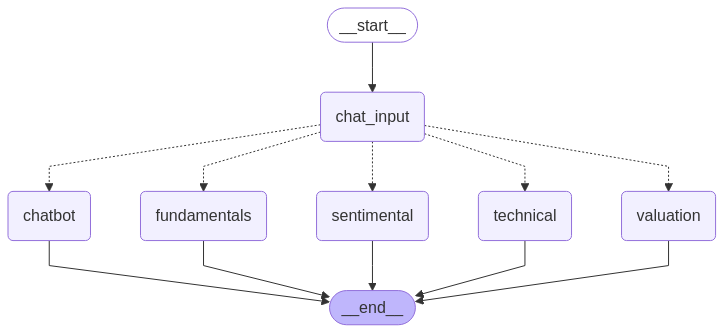

In [ ]:
## docker run -p 3000:3000 ghcr.io/jihchi/mermaid.ink 
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [3]:

user_input = [
    # Saudações gerais
    "Bom dia, como está?",
    "Olá, poderia me ajudar?",
    "Boa tarde, gostaria de algumas análises",
    "Oi, preciso de ajuda com investimentos",
    
    # Análises Técnicas
    "Realize uma análise técnica da PETROBRAS",
    "Realize uma análise técnica da PETROBRAS",
    "Quero ver a análise técnica da VALE",
    "Me mostre os indicadores técnicos da ITUB4",
    "Poderia fazer uma análise técnica da Banco do BRASIL?",
    "Como está o gráfico técnico da MAGAZ LUIZA?",
    
    # Análises Fundamentalistas
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Preciso dos fundamentos da PETROBRAS",
    "Qual a análise fundamental da VALE?",
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Faça uma análise fundamentalista da ITAU",
    "Como estão os fundamentos da WEG?",
    
    # Análises de Sentimento
    "Qual o sentimento do mercado sobre Unifique?",
    "Análise de sentimento para VALE, por favor",
    "Como está o sentimento para MULTIPLAN?",
    "Faça uma análise de sentimento da OI",
    "Qual a percepção do mercado sobre PETZ?",
    
    # Análises de Valuation
    "Qual o valor justo da AMERICANAS?",
    "Faça uma análise de valuation do Banco do AMAZONIA",
    "Preciso do valuation da BANDO MERCANTIL",
    "Me ajude com o valuation da ECORODOVIAS",
    "Quanto vale realmente a CEMIG?",
    
    # Combinações de Análises
    "Quero análise técnica e fundamental da PETR4",
    "Mostre o sentimento e valuation da VALE3",
    "Preciso de uma análise completa da BBDC3",
    "Como está BRASKEM em termos técnicos e sentimentais?",

    
    # Perguntas Específicas
    
    "Qual o melhor momento para comprar PETR4?",
    "Devo vender minha posição em GERDAU?",
    "É hora de investir em BRAVA?",
    "FLEURY está cara ou barata?",
    "Vale a pena entrar em MAGAZIN LUIZA agora?"
]

    # Configuração do stream
config = {"configurable": {"thread_id": "1"}}

for mess in user_input:
        # Configuração inicial do estado
    initial_state = {
            "messages": [HumanMessage(content=mess)],
            "ticker": "",  # Definindo o ticker explicitamente
            "method_analysis": "" , # Definindo o método de análise|
            
        }
    events = graph.invoke(
            initial_state,
            config=config,
            stream_mode="values",
        )
    
    

Não foi possível pegar os links da pagina 1!
Não foi possível pegar os titulos da pagina 1!
Não foi possível pegar as fontes da pagina 1!
Não foi possível pegar as datas da pagina 1!
Sem mais páginas!
Poucas noticias encontrada para o ticker FIQE3 no Yahoo Finance. Buscando noticias no Google
Error fetching URL: The read operation timed out
Error fetching URL: Client error '403 Forbidden' for url 'https://conteudos.xpi.com.br/acoes/relatorios/isps-tecpar-deal-macquarie/'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403
Error fetching URL: Redirect response '302 Found' for url 'https://br.advfn.com/noticias/PAPERBR/2025/artigo/95365594'
Redirect location: '/jornal/2025/02/unifique-aprova-pagamento-de-juros-sobre-o-capital-e-de-dividendos-intermediarios'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/302
Sem mais páginas!
Não foi possível pegar os links da pagina 1!
Não foi possível pegar os titulos da pagina 1

[*********************100%***********************]  1 of 1 completed


Nao tem returnOnEquity
Diferença entre valuation e cotação: nan%


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Diferença entre valuation e cotação: 421.94%


...

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Diferença entre valuation e cotação: -257.96%


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Diferença entre valuation e cotação: -19.44%


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
from langchain_core.prompts import ChatPromptTemplate

state = graph.get_state(config)

ChatPromptTemplate.from_messages(state.values["messages"]).pretty_print()

================================ Human Message =================================

Bom dia, como está?

================================== Ai Message ==================================

Bom dia! Estou bem, obrigado por perguntar! Estou aqui para ajudar com análises e informações sobre investimentos. Qual é o seu interesse? Você está procurando por informações sobre um investimento específico, ou gostaria de saber mais sobre um tipo de investimento em particular?

================================ Human Message =================================

Olá, poderia me ajudar?

================================== Ai Message ==================================

Olá! Estou aqui para ajudar com informações e análises sobre investimentos. Qual é o seu objetivo ou dúvida relacionada a investimentos? Você está procurando por informações sobre um tipo específico de investimento, como ações, fundos, ETFs ou imóveis? Ou talvez você tenha uma carteira de investimentos e precise de ajuda para otimizá-la? Esto

# Colocando lista

In [11]:
from langchain_core.prompts import PromptTemplate

class Prompts:
    def prompt_analysis_tecnica(self) -> PromptTemplate:
        prompt = PromptTemplate(
        input_variables=["query", "dados"],
        template="""
            
            You are a technical analyst specialized in interpreting financial indicators to identify market trends, entry, and exit points. Use the following technical data to provide a detailed analysis of the current asset situation and a possible trading strategy:

            Available Indicators:
            Moving Averages
            20 periods:
            100 periods:
            200 periods:
            Relative Strength Index (RSI - 14 periods)
            MACD and Signal Line:
            MACD:
            Signal:
            Bollinger Bands:
            Upper:
            Middle:
            Lower:
            Support and Resistance Levels (Pivot Points):
            Pivot Point:
            Supports:
            Resistances:
            VWAP (Volume Weighted Average Price)
            ADX (Average Directional Index - 14 periods)
            Analysis Objectives:
            Trend Identification:
            Is the price above or below the moving averages?
            Do the moving averages indicate an uptrend or downtrend?
            Does the ADX indicate a strong trend (>25) or a weak trend (<25)?
            Market Strength:
            Does the RSI suggest overbought conditions (>70) or oversold conditions (<30)?
            Is the MACD crossing the signal line, suggesting a potential entry/exit point?
            Support and Resistance:
            Is the current price near a significant support or resistance level?
            Do the Bollinger Bands indicate high volatility (expansion) or low volatility (contraction)?
            Possible Strategy:
            If in an uptrend: Identify buying points and profit targets.
            If in a downtrend: Identify selling points and downside targets.
            If in a ranging market: Suggest reversal or breakout strategies.
            Based on these factors, provide a detailed analysis of the current asset situation and a recommended course of action (buy, sell, or wait).
            .  

                                                                                                            
            REQUESTED ANALYSIS:
            Question: {query}
            Financial Data: {dados}
            
            
            Always response the questions in Portuguese.

        """,
    )
        return prompt
    
    def prompt_analise_sentimento(self) -> PromptTemplate:
        prompt = PromptTemplate(
        input_variables=["query", "noticias"],
        template="""
          You are an investment analyst specializing in Natural Language Processing (NLP). Your task is to evaluate the overall sentiment of recent news about a specific company and determine whether the current outlook is positive or negative for investment."

        📌 Model Input:
        A set of recent news articles about the company [COMPANY_NAME] collected from the internet.
        The news may include headlines, summaries, or full articles.
        
        Expected Output:
        1Sentiment Analysis
        For each news article, determine the predominant sentiment:
        Positive → Growth indicators, strong financial results, innovations, strategic acquisitions.
        Neutral → News with no direct impact or mixed information.
        Negative → Scandals, market declines, financial issues, internal crises.
        
        Assign a sentiment score (e.g., from -1 to +1).
        
        Overall Sentiment Score Calculation
        Based on the analyzed news, calculate an average sentiment index:
        Index ≥ +0.3 → Positive investment outlook.
        Index between -0.3 and +0.3 → Neutral outlook, caution advised.
        Index ≤ -0.3 → Negative outlook, not a good time to invest.
        
        Conclusion & Recommendation
        Is it a good time to invest?
        YES, positive outlook: Overall sentiment is favorable, and the company has good prospects.
        CAUTION, mixed outlook: There are uncertainties or market volatility.
        NO, negative outlook: Many negative news stories indicate high risk.     
                                                    
                                                                                                   
        REQUESTED ANALYSIS:
        Question: {query}
        Financial New Data: {noticia}
        
        Always response the questions in Portuguese.

      """,
    )
        return prompt
    def prompt_analise_fundamentalista(self) -> PromptTemplate:
        prompt = PromptTemplate(
        input_variables=["query", "dados"],
        template="""
                You are a fundamental analyst, responsible for assessing the financial health, operational performance, and investment prospects of companies based on financial indicators. Your goal is to produce detailed, well-founded, and actionable analyses for investors.

                The indicators you receive include the following data:

                Resultados financeiros: receita_liquida, resultado_bruto, ebit, ebitda, lucro_liquido, lucro_por_acao.
                Fluxos de caixa: fluxo_caixa_operacional, fluxo_caixa_investimentos, fluxo_caixa_financiamento, fluxo_caixa_livre_tres_meses.
                Investimentos e despesas: capex_tres_meses.
                Valuation: preço_lucro, preço_receita_líquida,  preço_fcf, preço_ebit, ev_ebit, ev_ebitda, enterprise_value, market_cap_empresa.
                Dividendo: dividend_yield.
                Balanço patrimonial: ativo_total, divida_bruta, divida_liquida, patrimonio_liquido, valor_patrimonial_acao.
                Indicadores de rentabilidade e eficiência: retorno_sobre_capital_tangivel_inicial, retorno_sobre_capital_investido_inicial, retorno_sobre_patrimonio_liquido_inicial, margem_bruta, margem_liquida, giro_do_ativo_inicial, alavancagem_financeira.
                Riscos e alavancagem:  passivo_patrimonio_liquido.
                Your Task:
                Analyze indicators: Identify the company’s strengths and weaknesses based on the provided indicators.
                Generate actionable insights: Provide recommendations for investors, such as "buy," "hold," or "sell," with clear justifications based on the data.
                Identify trends: Evaluate historical performance trends and possible implications for the future.
                Communicate results: Present your analysis clearly and concisely, suitable for both beginners and experienced investors.
                Example of Expected Response:

                Evaluated Company: [company name or ticker]
                Analysis Summary: Provide an overall assessment of the company based on the indicators.
                Strengths: Highlight positive metrics, such as high net_income, strong margins, or low net_debt.
                Weaknesses: Identify areas of concern, such as low net_margin or high net_debt_to_ebitda.
                Recommendation: Based on your analysis, provide a recommendation (buy, hold, or sell) with justification.
                                                    
                                                                                                   
        REQUESTED ANALYSIS:
        Question: {query}
        Financial Data: {dados}
        
        
        Always response the questions in Portuguese.

      """,
    )
        return prompt
    
    def prompt_valuation(self) -> PromptTemplate:
        prompt = PromptTemplate(
        input_variables=[
            "query",
            "precos_atual_valuations",
            "indicadores_valuation_fluxo",
            "valuation_metodo_gordon",
            "valuation_fluxo_caixa",
        ],
        template="""
        You are an agent specialized in company valuation, responsible for determining whether a company is undervalued or overvalued.

        To achieve this, you receive two valuation estimates:
        1️ Discounted Cash Flow (DCF) Valuation
        2️ Gordon Growth Model Valuation (Perpetual Growth)

        Additionally, you have access to the current stock price, allowing you to compare the estimates with the market value.

        Data Description
        1. Stock Values
        You receive the current stock price and the estimated values from both valuation methods.

        2. Gordon Growth Model Valuation

        Based on the sustainable growth of dividends over time.
        The data includes median dividend, risk-free rate, beta, CAPM, sustainable growth rate, and estimated stock valuation.
        
        3. Discounted Cash Flow (DCF) Valuation

        Based on the projection of future cash flows, discounted to present value.
        The data includes annual revenue, EBIT, tax, CAPEX, depreciation, cash flow, and present value of future cash flows.
        
        4. Inputs Used for DCF Calculation

        Indicators used in the projection, such as EBIT margin, last reported revenue, revenue variation, depreciation-to-CAPEX ratio, CAPEX-to-revenue ratio, WACC, number of shares, total debt, available cash, other assets, liabilities, and working capital requirements.
        Model Task
        
        1. Comparison Between Valuation Methods

        Is the valuation from the Gordon Growth Model close to the valuation from the Discounted Cash Flow method?
        If there is a significant difference, what factors might be influencing this discrepancy?
        
        2. Profitability and Financial Sustainability Analysis

        Does the company have a positive or negative cash flow over the projected years?
        Is CAPEX excessively high, potentially compromising future cash flow?
        Does the company’s value generation justify the calculated valuation?
        
        3. Risks and Inconsistencies

        Are revenue and EBIT growth rates sustainable, or do they suggest a possible overestimation?
        Is the level of debt concerning? Does the debt-to-cash ratio indicate financial risks?
        Is the WACC appropriate for discounting future cash flows?
        
        4. Conclusion and Recommendation

        Based on the calculations, is the company undervalued or overvalued?
        What would be a recommendation for investors based on the analyzed data?
        Expected Response Format
        The model must provide a structured and objective analysis, answering each question based on the given data.
        The response should include numerical comparisons, justifications for discrepancies between valuation methods, and considerations on financial risks.

        REQUESTED ANALYSIS:
        Question: {query}
        Precos dos valuations e atual: {precos_atual_valuations}
        Inputs passado para estimar fluxo de caixa: {indicadores_valuation_fluxo}
        Valuation Fluxo Caixa: {valuation_fluxo_caixa}
        Valuation Metodo Gordon: {valuation_metodo_gordon}    
        
        Always response the questions in Portuguese.

      """,
    )        
        return prompt

In [ ]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
from chat_bots import (ChatAnaliseTecnica,  
                      ChatSentimento, 
                      ChatValuation, 
                      ChatFundamentalistas,
                      ChatValuationAsync,
                      ChatFundamentalistasAsync,
                      ChatSentimentoAsync,
                      ChatAnaliseTecnicaAsync)
from tratando_dados import TratandoDadosIndicadores, TratandoDadosValuation, TratarDadosNoticias, tratando_dados_fundamentalistas
from chat_bots import get_secret_key
from pydantic import SecretStr
from typing import Iterator, List, Any
import os
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from selenium import webdriver
import warnings
import pandas as pd
import asyncio
warnings.filterwarnings('ignore')

load_dotenv()

try:
    api_secret_groq = get_secret_key("GROQ_API_KEY")
except KeyError as exc:
    raise ValueError("API key inválida ou não definida") from exc

api_key = os.getenv("GROQ_API_KEY")


llm = ChatGroq(
    api_key=api_key,
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    #model="qwen-2.5-coder-32b",
    temperature=0,
    stop_sequences=None,
)

memory = MemorySaver()

class State(TypedDict):
    messages: Annotated[list, add_messages]
    ticker: str
    method_analysis: str
    dados_input : str
    
    
class ModeloAnaliseTecnicaAsync():
    def __init__(
        self,
        query: str,
        ticker: str,
        periodo: str = "18Y",
        intervalo: str = "1mo",
        modelo_llm: str = "meta-llama/llama-4-scout-17b-16e-instruct",
        stream: bool = False,
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        self.query = query
        self.ticker = ticker
        self.periodo = periodo
        self.intervalo = intervalo
        self.modelo_llm = modelo_llm
        self.stream = stream
        self.api_secret = api_secret

    def dados_indicadores_tecnicas(self) -> List[Any]:
        ind = TratandoDadosIndicadores(
            ticker=self.ticker, periodo=self.periodo, intervalo=self.intervalo
        )
        return ind.indicadores_data_loader()

    async def chat_analise_tecnica(self) -> str | Iterator[str]:
        dados_tecnicas = self.dados_indicadores_tecnicas()
        response = await ChatAnaliseTecnicaAsync(
            query=self.query,
            dados=dados_tecnicas,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        if '</think>' in response:
            response = response.split('</think>')[1]
        return response

class ModeloValuationAsync:
    def __init__(
        self,
        ticker: str,
        query: str,
        anos_projecao: int = 5,
        taxa_crescimento_perpetuidade: float = 0.014,
        calculo_necessidade_capital_de_giro: bool = False,
        stream: bool = False,
        modelo_llm: str = "meta-llama/llama-4-scout-17b-16e-instruct",
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        self.query = query
        self.ticker = ticker
        self.anos_projecao = anos_projecao
        self.taxa_crescimento_perpetuidade = taxa_crescimento_perpetuidade
        self.calculo_necessidade_capital_de_giro = calculo_necessidade_capital_de_giro
        self.stream = stream
        self.modelo_llm = modelo_llm
        self.api_secret = api_secret

    def tratando_ticker(self) -> str:
        if ".SA" in self.ticker:
            acao = self.ticker
        else:
            acao = f"{self.ticker}.SA"
        return acao

    def dados_valuation(self) -> tuple[str, str, str, str]:
        dados_valu = TratandoDadosValuation(
            ticker=self.tratando_ticker(),
            anos_projecao=5,
            taxa_crescimento_perpetuidade=self.taxa_crescimento_perpetuidade,
            calculo_necessidade_capital_de_giro=self.calculo_necessidade_capital_de_giro,
        )
        markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores = (
            dados_valu.dados_valuation()
        )
        return markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores

    async def chat_valuation(self) -> str | Iterator[str]:
        markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores = (
            self.dados_valuation()
        )

        response = await ChatValuationAsync(
            query=self.query,
            precos_atual_valuations=markdow_preco,
            indicadores_valuation_fluxo=markdow_indicadores,
            valuation_metodo_gordon=markdow_gordon,
            valuation_fluxo_caixa=markdow_fluxo,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        if '</think>' in response:
            response = response.split('</think>')[1]

        return response
    

class ModeloSentimentoAsync:
    def __init__(
        self,
        ticker: str,
        query: str,
        modelo_llm: str = "meta-llama/llama-4-scout-17b-16e-instruct",
        stream: bool = False,
        api_secret_groq: SecretStr | None = api_secret_groq,
        api_secret_serper: SecretStr | None = None,
    ) -> None:
        self.ticker = ticker
        self.query = query
        self.modelo_llm = modelo_llm
        self.stream = stream
        self.api_secret_groq = api_secret_groq
        self.api_secret_serper = api_secret_serper

    def option(self) -> webdriver.ChromeOptions:
        chrome_options = webdriver.ChromeOptions()
        chrome_options.add_argument("--headless")
        chrome_options.add_argument("--no-sandbox")
        chrome_options.add_argument("--disable-dev-shm-usage")
        chrome_options.add_argument("--disable-gpu")
        chrome_options.add_argument("--disable-features=NetworkService")
        chrome_options.add_argument("--window-size=1920x1080")
        chrome_options.add_argument("--disable-features=VizDisplayCompositor")
        return chrome_options

    def dados_sentimento(self) -> str:
        dados_noticias = TratarDadosNoticias(
            acao=self.ticker,
            options=self.option(),
            api_secret_groq=self.api_secret_groq,
            api_secret_serper=self.api_secret_serper,
        )
        dados_new = dados_noticias.clean_chat_html_bs4()
        return dados_new

    async def chat_sentimento(self) -> str | Iterator[str]:
        dados_new = self.dados_sentimento()
        response = await ChatSentimentoAsync(
            query=self.query,
            noticia=dados_new,
            api_secret=self.api_secret_groq,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        if '</think>' in response:
            response = response.split('</think>')[1]
        return response


class ModeloFundamentosAsync:
    def __init__(
        self,
        ticker: str,
        query: str,
        stream: bool = False,
        modelo_llm: str = "meta-llama/llama-4-scout-17b-16e-instruct",
        dados_inicio: str = "2022-06-01",
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        
        self.query = query
        self.ticker = ticker
        self.stream = stream
        self.modelo_llm = modelo_llm
        self.dados_inicio = dados_inicio
        self.api_secret = api_secret

    async def dados_fundamentalistas(self) -> List[Any]:
        return await tratando_dados_fundamentalistas(self.ticker, self.dados_inicio)

    async def chat_fundamentalistas(self) -> str | Iterator[str]:
        dados_fundamentalistas = await self.dados_fundamentalistas()
        response = await ChatFundamentalistasAsync(
            query=self.query,
            dados=dados_fundamentalistas,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        if '</think>' in response:
                response = response.split('</think>')[1]
        return response

async def analise_investimento(state: State) -> State:

    ticker = state['ticker']

    tecnica = ModeloAnaliseTecnicaAsync(
            query=f"Qual a analise tecnica da {ticker}",
            ticker=ticker,
        )
    fundamentos = ModeloFundamentosAsync(
            query=f"Qual o fundamentos da {ticker}",
            ticker=ticker,
        
        )
    valuation = ModeloValuationAsync(
            query=f"Qual o valuation da {ticker}",
            ticker=ticker,
        )
    sentimento = ModeloSentimentoAsync(
            query=f"Qual o sentimento da {ticker}",
            ticker=ticker,
        )
     
    resultados = await asyncio.gather(
            tecnica.chat_analise_tecnica(),
            fundamentos.chat_fundamentalistas(),
            valuation.chat_valuation(),
            sentimento.chat_sentimento()
        )
        
    resultados = "\n".join(resultados)
        
    state['dados_input'] = resultados
        
    return state
    

async def chat_input(state: State) -> State:
    # Carrega dados das empresas
    empresas_df = pd.read_csv('https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv', encoding='utf-8')
    
    # Template do prompt
    prompt = """
    Você é um assistente especializado em investimentos. Por favor, extraia as seguintes informações da mensagem do usuário:
    1. O ticker (código) da ação
    2. Se for pedido para fazer uma analise sobre alguma ação responda como metodo "analise_investimento". Exemplo:" Devo investir na pretrobras".
    3. Se não houver o método, retorne chatbot para continuar a conversa
    4. Se não houver o ticker, mas tiver o nome da empresa, procure no {empresas_tickers} o ticker correspondente ao nome da empresa
    
    Responda apenas com o ticker com letras maiusculas: 'BBDC4' e o método no formato minusculo 'analise_investimento', traga a resposta do ticker e o método como uma lista de strings:
    TICKER: ticker
    MÉTODO: método
    """
    empresas_tickers = "\n".join([f"{empresa} ({ticker})" for empresa, ticker in 
                                zip(empresas_df['Empresa'], empresas_df['tic'])])
    prompt = prompt.format(empresas_tickers=empresas_tickers)
    
    # Pegar a última mensagem do usuário
    last_message = state["messages"][-1]
    
    
    # Fazer a chamada ao LLM
    response = await llm.ainvoke([
        HumanMessage(content=prompt),
        HumanMessage(content=last_message.content)
    ])
    
    response_text = response.content
    
    
    ticker = ''
    metodo_analise = ''
    
    for line in response_text.split('\n'):
        if line.startswith('TICKER:'):
            ticker = line.split(':')[1].strip()
        elif line.startswith('MÉTODO:'):
            metodo_analise = line.split(':')[1].strip()   
    
    # Update state
    state['ticker'] = ticker
    state['method_analysis'] = metodo_analise
    
    return state

def should_continue(state: State):
    if state["method_analysis"] == "analise_investimento" and state['ticker']:
        return 'analise_investimento'
    return "chatbot"

graph_builder = StateGraph(State)

async def chatbot(state: State) -> dict:
    """
    Processa as mensagens do usuário e retorna uma resposta formatada.
    """
    try:
        
        # Criar o prompt do sistema
        system_message = SystemMessage(content=f"""
       Você é um assistente especializado em análise de investimentos no mercado brasileiro.
        
        Voce recebe os seguintes dados {state['dados_input']}. Nesses dados voce recebe informacao de analise técnica, analise fundamentalista, analise de sentimento e analise de valuation de acoes expecificado pelos usuarios.
        As analises nesses dados estao divididos pelo seguinte caracteres:
        - #########Technical Analysis#######  = Dentro dessa analise tem analise tecnica da acao.
        - ##########Fundamental Analysis######## = Dentro dessa analise tem a analise dos balancos da acao.
        - ############Valuation Analysis############ = Dentro dessa te a estimativa do valuation da acao.
        - #########Sentiment Analysis##### =  Dentro dessa temos a analise de noticias sobre a acao.
        
        Diretrizes:
        - Seja conciso e direto nas respostas
        - Use linguagem acessível, mas profissional
        - Quando não tiver certeza, admita as limitações
        - Sempre mencione os riscos envolvidos em investimentos
        - Evite recomendações diretas de compra/venda
        
        Voce deve dar o nivel de confianca da analise.
        Indique se analisando as entradas do agentes, a recomendacao e de compra, venda ou manter a acao.
        
        
        A RESPOSTA DEVE SER NO SEGUINTE FORMATO:
        
        | Tipo de Análise        | Resumo                                      |
        |------------------------|---------------------------------------------|
        | Valuation Analysis     | ...                                         |
        | Sentiment Analysis     | ...                                         |
        | Technical Analysis     | ...                                         |
        | Fundamental Analysis   | ...                                         |
      
      
        ##Analises de Investimentos
        - Comentario sobre o ativo
        
        ## Nivel de confianca 
        
        ### Consideracoes Finais
        Aqui coloque consideracao finais sobre as analises das acoes:
           
---

    *Observação:*  
    Caso não haja dados suficientes sobre a empresa, responda normalmente com base em uma conversa genérica.
        
        """)
        
        # Pegar a última mensagem do usuário
        last_message = state["messages"][-1]
        
        
        # Montar a lista de mensagens para o LLM
        messages = [
            system_message,
            HumanMessage(content=f"{last_message.content}")
        ]
        
        llm = ChatGroq(
        api_key=api_key,
        #model="meta-llama/llama-4-scout-17b-16e-instruct",
        model="qwen-qwq-32b",
        temperature=0,
        stop_sequences=None,
    )
        
        # Fazer a chamada ao LLM
        response = await llm.ainvoke(messages)
        
        # Retornar o estado atualizado
        return {
            "messages": [AIMessage(content=response.content)],
            "ticker": state.get("ticker", ""),
            "method_analysis": state.get("method_analysis", ""),
            "dados_input": state.get('dados_input', "")
        }
        
    except Exception as e:
        return {
            "messages": [AIMessage(content=f"Erro no processamento: {str(e)}")],
            "ticker": state.get("ticker", ""),
            "method_analysis": state.get("method_analysis", ""),
            "dados_input" : ""
 
        }
        
memory = MemorySaver()

graph_builder.add_node("chat_input", chat_input)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node('analise_investimento', analise_investimento)
graph_builder.set_entry_point("chat_input")
graph_builder.add_conditional_edges(
    "chat_input",
    should_continue,
    {   
        "analise_investimento": "analise_investimento",
        "chatbot": "chatbot",        
    },
)
graph_builder.add_edge("analise_investimento", "chatbot")
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile(checkpointer=memory)

USER_AGENT environment variable not set, consider setting it to identify your requests.


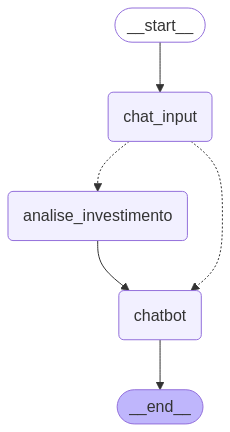

In [2]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
import time
user_input = [
    # Saudações gerais
    "Bom dia, como está?",
    "Olá, poderia me ajudar?",
    "Boa tarde, gostaria de algumas análises",
    "Oi, preciso de ajuda com investimentos",
    
    # Análises Técnicas
    "Realize uma análise técnica da PETROBRAS",
    "Quero ver a análise técnica da VALE",
    "Me mostre os indicadores técnicos da ITUB4",
    "Poderia fazer uma análise técnica da Banco do BRASIL?",
    "Como está o gráfico técnico da MAGAZ LUIZA?",
    
    # Análises Fundamentalistas
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Preciso dos fundamentos da PETROBRAS",
    "Qual a análise fundamental da VALE?",
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Faça uma análise fundamentalista da ITAU",
    "Como estão os fundamentos da WEG?",
    
    # Análises de Sentimento
    "Qual o sentimento do mercado sobre Unifique?",
    "Análise de sentimento para VALE, por favor",
    "Como está o sentimento para MULTIPLAN?",
    "Faça uma análise de sentimento da OI",
    "Qual a percepção do mercado sobre PETZ?",
    
    # Análises de Valuation
    "Qual o valor justo da AMERICANAS?",
    "Faça uma análise de valuation do Banco do AMAZONIA",
    "Preciso do valuation da BANDO MERCANTIL",
    "Me ajude com o valuation da ECORODOVIAS",
    "Quanto vale realmente a CEMIG?",
    
    # Combinações de Análises
    "Quero análise técnica e fundamental da PETR4",
    "Mostre o sentimento e valuation da VALE3",
    "Preciso de uma análise completa da BBDC3",
    "Como está BRASKEM em termos técnicos e sentimentais?",

    
    # Perguntas Específicas
    
    "Qual o melhor momento para comprar PETR4?",
    "Devo vender minha posição em GERDAU?",
    "É hora de investir em BRAVA?",
    "FLEURY está cara ou barata?",
    "Vale a pena entrar em MAGAZIN LUIZA agora?"
]


#user_input = ["Quero análise técnica e fundamental da PETR4","Boa tarde, gostaria de algumas análises"]

    # Configuração do stream
config = {"configurable": {"thread_id": "1"}}

for mess in user_input:
        # Configuração inicial do estado
        
    start = time.time()
    initial_state = {
            "messages": [HumanMessage(content=mess)],
            "ticker": "",  # Definindo o ticker explicitamente
            "method_analysis": "" , # Definindo o método de análise|
            "dados_input" : ""
            
        }
 
    events = await graph.ainvoke(
            initial_state,
            config=config,
            stream_mode="values",
        )
    print(mess)
    end = time.time()
    print(f'O tempo de execucao foi de {end - start}')
    
    

In [4]:
from langchain_core.prompts import ChatPromptTemplate

state = graph.get_state(config)

ChatPromptTemplate.from_messages(state.values["messages"]).pretty_print()

================================ Human Message =================================

Bom dia, como está?

================================== Ai Message ==================================

Bom dia! Estou bem, obrigado por perguntar. Como posso ajudar você hoje com relação aos investimentos no mercado brasileiro?

================================ Human Message =================================

Olá, poderia me ajudar?

================================== Ai Message ==================================

Claro, posso ajudar! Por favor, forneça os dados de análise técnica, fundamentalista, de sentimento e de valuation para que eu possa fazer uma análise completa e fornecer um resumo detalhado.

Se você não tiver todos os dados, posso ainda fornecer uma análise baseada nas informações disponíveis.

================================ Human Message =================================

Boa tarde, gostaria de algumas análises

================================== Ai Message =================================

# Melhorando o agente

In [3]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
from chat_bots import (
                      ChatValuationAsync,
                      ChatFundamentalistasAsync,
                      ChatSentimentoAsync,
                      ChatAnaliseTecnicaAsync)
from tratando_dados import TratandoDadosIndicadores, TratandoDadosValuation, TratarDadosNoticias, tratando_dados_fundamentalistas
from chat_bots import get_secret_key
from pydantic import SecretStr
from typing import Iterator, List, Any
import os
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from selenium import webdriver
import warnings
import pandas as pd
import asyncio
warnings.filterwarnings('ignore')

load_dotenv()

try:
    api_secret_groq = get_secret_key("GROQ_API_KEY")
except KeyError as exc:
    raise ValueError("API key inválida ou não definida") from exc

api_key = os.getenv("GROQ_API_KEY")

llm = ChatGroq(
    api_key=api_key,
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    #model="qwen-2.5-coder-32b",
    temperature=0,
    stop_sequences=None,
)

memory = MemorySaver()

class State(TypedDict):
    messages: Annotated[list, add_messages]
    ticker: str
    method_analysis: list[str]
    dados_input : str
    next: str
    
    
class ModeloAnaliseTecnicaAsync():
    def __init__(
        self,
        query: str,
        ticker: str,
        periodo: str = "18Y",
        intervalo: str = "1mo",
        modelo_llm: str = "meta-llama/llama-4-scout-17b-16e-instruct",
        stream: bool = False,
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        self.query = query
        self.ticker = ticker
        self.periodo = periodo
        self.intervalo = intervalo
        self.modelo_llm = modelo_llm
        self.stream = stream
        self.api_secret = api_secret

    def dados_indicadores_tecnicas(self) -> List[Any]:
        ind = TratandoDadosIndicadores(
            ticker=self.ticker, periodo=self.periodo, intervalo=self.intervalo
        )
        return ind.indicadores_data_loader()

    async def chat_analise_tecnica(self) -> str | Iterator[str]:
        dados_tecnicas = self.dados_indicadores_tecnicas()
        response = await ChatAnaliseTecnicaAsync(
            query=self.query,
            dados=dados_tecnicas,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        if '</think>' in response:
            response = response.split('</think>')[1]
        return response

class ModeloValuationAsync:
    def __init__(
        self,
        ticker: str,
        query: str,
        anos_projecao: int = 5,
        taxa_crescimento_perpetuidade: float = 0.014,
        calculo_necessidade_capital_de_giro: bool = False,
        stream: bool = False,
        modelo_llm: str = "meta-llama/llama-4-scout-17b-16e-instruct",
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        self.query = query
        self.ticker = ticker
        self.anos_projecao = anos_projecao
        self.taxa_crescimento_perpetuidade = taxa_crescimento_perpetuidade
        self.calculo_necessidade_capital_de_giro = calculo_necessidade_capital_de_giro
        self.stream = stream
        self.modelo_llm = modelo_llm
        self.api_secret = api_secret

    def tratando_ticker(self) -> str:
        if ".SA" in self.ticker:
            acao = self.ticker
        else:
            acao = f"{self.ticker}.SA"
        return acao

    def dados_valuation(self) -> tuple[str, str, str, str]:
        dados_valu = TratandoDadosValuation(
            ticker=self.tratando_ticker(),
            anos_projecao=5,
            taxa_crescimento_perpetuidade=self.taxa_crescimento_perpetuidade,
            calculo_necessidade_capital_de_giro=self.calculo_necessidade_capital_de_giro,
        )
        markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores = (
            dados_valu.dados_valuation()
        )
        return markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores

    async def chat_valuation(self) -> str | Iterator[str]:
        markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores = (
            self.dados_valuation()
        )

        response = await ChatValuationAsync(
            query=self.query,
            precos_atual_valuations=markdow_preco,
            indicadores_valuation_fluxo=markdow_indicadores,
            valuation_metodo_gordon=markdow_gordon,
            valuation_fluxo_caixa=markdow_fluxo,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        if '</think>' in response:
            response = response.split('</think>')[1]

        return response
    

class ModeloSentimentoAsync:
    def __init__(
        self,
        ticker: str,
        query: str,
        modelo_llm: str = "meta-llama/llama-4-scout-17b-16e-instruct",
        stream: bool = False,
        api_secret_groq: SecretStr | None = api_secret_groq,
        api_secret_serper: SecretStr | None = None,
    ) -> None:
        self.ticker = ticker
        self.query = query
        self.modelo_llm = modelo_llm
        self.stream = stream
        self.api_secret_groq = api_secret_groq
        self.api_secret_serper = api_secret_serper

    def option(self) -> webdriver.ChromeOptions:
        chrome_options = webdriver.ChromeOptions()
        chrome_options.add_argument("--headless")
        chrome_options.add_argument("--no-sandbox")
        chrome_options.add_argument("--disable-dev-shm-usage")
        chrome_options.add_argument("--disable-gpu")
        chrome_options.add_argument("--disable-features=NetworkService")
        chrome_options.add_argument("--window-size=1920x1080")
        chrome_options.add_argument("--disable-features=VizDisplayCompositor")
        return chrome_options

    def dados_sentimento(self) -> str:
        dados_noticias = TratarDadosNoticias(
            acao=self.ticker,
            options=self.option(),
            api_secret_groq=self.api_secret_groq,
            api_secret_serper=self.api_secret_serper,
        )
        dados_new = dados_noticias.clean_chat_html_bs4()
        return dados_new

    async def chat_sentimento(self) -> str | Iterator[str]:
        dados_new = self.dados_sentimento()
        response = await ChatSentimentoAsync(
            query=self.query,
            noticia=dados_new,
            api_secret=self.api_secret_groq,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        if '</think>' in response:
            response = response.split('</think>')[1]
        return response


class ModeloFundamentosAsync:
    def __init__(
        self,
        ticker: str,
        query: str,
        stream: bool = False,
        modelo_llm: str = "meta-llama/llama-4-scout-17b-16e-instruct",
        dados_inicio: str = "2022-06-01",
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        
        self.query = query
        self.ticker = ticker
        self.stream = stream
        self.modelo_llm = modelo_llm
        self.dados_inicio = dados_inicio
        self.api_secret = api_secret

    async def dados_fundamentalistas(self) -> List[Any]:
        return await tratando_dados_fundamentalistas(self.ticker, self.dados_inicio)

    async def chat_fundamentalistas(self) -> str | Iterator[str]:
        dados_fundamentalistas = await self.dados_fundamentalistas()
        response = await ChatFundamentalistasAsync(
            query=self.query,
            dados=dados_fundamentalistas,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        if '</think>' in response:
                response = response.split('</think>')[1]
        return response

In [4]:
from typing import Literal
from typing_extensions import TypedDict
from langgraph.graph import MessagesState, END
from langgraph.types import Command
async def process_technical(state: State) -> Command[Literal["supervisor"]]:
    """
    Executa a análise técnica para o ticker especificado no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de análise técnica assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise técnica
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos techincal')
   
    ticker = state['ticker']
    query = state["messages"][-1]
    modelo = ModeloAnaliseTecnicaAsync(ticker=ticker, query=query)
    response = await modelo.chat_analise_tecnica()
    
    dados_input = state['dados_input']
    
    response = dados_input.join(response)
    
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="tecnica")
            ]
        },
        goto="supervisor",
    )
    
    

async def process_valuation(state: State) -> Command[Literal["supervisor"]]:
    """
    Executa a análise de valuation para o ticker especificado no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de valuation assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise de valuation
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos valuation')
    
    ticker = state['ticker']
    query = state["messages"][-1]
    modelo = ModeloValuationAsync(ticker=ticker, query=query)
    response = await modelo.chat_valuation()
    dados_input = state['dados_input']
    response = dados_input.join(response)
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="valuation")
            ]
        },
        goto="supervisor",
        )
    
        
    
    
async def process_sentimetal(state: State) -> Command[Literal["supervisor"]]:
    """
    Executa a análise de sentimento para o ticker especificado no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de análise de sentimento assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise de sentimento
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos sentimental')
    
    ticker = state['ticker']
    query = state["messages"][-1]
    modelo = ModeloSentimentoAsync(ticker=ticker, query=query)
    response= await modelo.chat_sentimento()
    dados_input = state['dados_input']
    response = dados_input.join(response)
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="valuation")
            ]
        },
        goto="supervisor",
        )
        
    
async def process_fundamental(state: State) -> Command[Literal["supervisor"]]:
    """
    Executa a análise fundamentalista para o ticker especificado no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de análise fundamentalista assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise fundamentalista
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos fundamentos')
    
    ticker = state['ticker']
    query = state["messages"][-1]
    modelo = ModeloFundamentosAsync(ticker=ticker, query=query)
    response = await modelo.chat_fundamentalistas()
    dados_input = state['dados_input']
    response = dados_input.join(response)
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="valuation")
            ]
        },
        goto="supervisor",
        )
    

async def analise_investimento(state: State) -> Command[Literal["supervisor"]]:
    print('entrei no analis investimento')
    ticker = state['ticker']

    tecnica = ModeloAnaliseTecnicaAsync(
            query=f"Qual a analise tecnica da {ticker}",
            ticker=ticker,
        )
    fundamentos = ModeloFundamentosAsync(
            query=f"Qual o fundamentos da {ticker}",
            ticker=ticker,
        
        )
    valuation = ModeloValuationAsync(
            query=f"Qual o valuation da {ticker}",
            ticker=ticker,
        )
    sentimento = ModeloSentimentoAsync(
            query=f"Qual o sentimento da {ticker}",
            ticker=ticker,
        )
     
    response = await asyncio.gather(
            tecnica.chat_analise_tecnica(),
            fundamentos.chat_fundamentalistas(),
            valuation.chat_valuation(),
            sentimento.chat_sentimento()
        )
        
    dados_input = state['dados_input']
    
    response = dados_input.join(response)
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="valuation")
            ]
        },
        goto="supervisor",
        )

In [5]:
async def chat_input(state: State) -> State:
    """
    Processa a última mensagem do usuário para identificar um ticker de ação e o método de análise solicitado.

    Esta função lê uma lista de empresas e seus tickers de uma fonte externa.
    Constrói um prompt para um modelo de linguagem grande (LLM) instruindo-o a extrair
    o ticker da ação e o tipo de análise (fundamentals/valuation/sentimental/technical/Analise_investimento/chatbot)
    da última mensagem do usuário no estado fornecido.

    A função envia o prompt e a mensagem do usuário para o LLM, analisa a resposta
    para extrair o ticker e o método. Realiza uma verificação básica para garantir
    que o ticker extraído seja válido ou encontra um semelhante se necessário.
    Finalmente, atualiza o dicionário de estado com o ticker identificado e o método
    de análise e retorna o estado atualizado.

    Args:
        state (State): Um dicionário representando o estado atual da conversa,
                       espera-se que contenha uma chave "messages" com uma lista
                       de mensagens, onde a última é a do usuário.

    Returns:
        State: O dicionário de estado atualizado com as chaves 'ticker' e
               'method_analysis' preenchidas com os valores extraídos da
               resposta do LLM. O ticker pode ser uma string vazia se nenhum
               for identificado. O método de análise será um dos seguintes:
               fundamentals/valuation/sentimental/technical/Analise_investimento/chatbot.
    """
    
    print('Entrei na chat imput')
    
    empresas_df = pd.read_csv('https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv', encoding='utf-8')
    
    prompt = """
    Você é um assistente especializado em investimentos do mercado brasileiro. Extraia precisamente as seguintes informações:
    
    1. O ticker (código) da ação mencionada na mensagem do usuário. Se houver múltiplos tickers, identifique qual está sendo solicitado para análise.
    2. O método de análise desejado (fundamentals, valuation, sentimental, technical). 
    3. Se for dado exemplos parecido com "Analise essa petrobras" ou "Vale apena investir na vale" responda (Analise_investimento).
    4. Se o usuário apenas mencionar uma empresa sem pedir análise específica, ainda extraia o ticker e defina o método como .
    5. Se não houver menção a nenhuma empresa ou ticker, retorne o método como "chatbot".
    
    Regras para identificação de tickers:
    - Tickers brasileiros geralmente terminam com números (ex: PETR4, VALE3)
    - Se o usuário mencionar apenas o nome da empresa (ex: "Petrobras"), identifique o ticker correto ({empresas_tickers})
    - Se houver ambiguidade, prefira o ticker mais líquido (geralmente terminados em 3 ou 4)
    - Se o usuário mencionar apenas o setor (ex: "bancos"), não retorne ticker específico
    
    Formato de resposta (apenas):
    <FORMATO RESPOSTAS>
    TICKER: [ticker em letras maiúsculas ou vazio se não identificado]
    MÉTODO: [fundamentals/valuation/sentimental/technical/Analise_investimento/chatbot]
    <FORMATO RESPOSTAS>
    """
    
    empresas_tickers = "\n".join([f"{empresa} ({ticker})" for empresa, ticker in 
                                zip(empresas_df['Empresa'], empresas_df['tic'])])
    prompt = prompt.format(empresas_tickers=empresas_tickers)
    
    # Pegar a última mensagem do usuário
    last_message = state["messages"][-1]
    
    # Fazer a chamada ao LLM
    response = await llm.ainvoke([
        HumanMessage(content=prompt),
        HumanMessage(content=last_message.content)
    ])
    
    response_text = response.content
    
    ticker = ''
    metodo_analise = 'chatbot'
    
    # Extração mais robusta
    for line in response_text.split('\n'):
        if line.startswith('TICKER:'):
            ticker = line.split(':')[1].strip()
        elif line.startswith('MÉTODO:'):
            metodo_analise = line.split(':')[1].strip()
    
    if ticker:
        if ticker not in empresas_df['tic'].values:
            similar_tickers = empresas_df[empresas_df['tic'].str.contains(ticker[:2])]['tic'].tolist()
            if similar_tickers:
                ticker = similar_tickers[0]
                
    print(f"Ticker extraído: {ticker}")
    print(f"Método de análise: {metodo_analise}")
    
    state['ticker'] = ticker
    state['method_analysis'] = [metodo_analise]
    
    return state

In [6]:
async def chatbot(state: State) -> dict:
    """
    Gera uma resposta consolidada de análise de investimentos usando um LLM.

    Esta função constrói um prompt detalhado para um LLM (ChatGroq),
    fornecendo-lhe os resultados das análises anteriores (técnica, fundamentalista,
    sentimento, valuation) armazenados em `state['dados_input']` e a última
    mensagem do usuário de `state['messages']`.

    O LLM é instruído a agir como um assistente de investimentos, resumir
    cada tipo de análise, fornecer um comentário geral sobre o ativo,
    indicar um nível de confiança e considerações finais (incluindo riscos),
    formatando a saída em Markdown.

    Args:
        state (State): O dicionário de estado atual, que deve conter:
            - 'dados_input': Uma lista de strings, cada uma representando
                             o resultado de uma análise prévia, separadas
                             por marcadores específicos (ex: '###Technical Analysis###').
            - 'messages': Uma lista de mensagens da conversa, onde a última
                          é a consulta mais recente do usuário.
            - 'ticker': (Opcional) O ticker da ação sendo analisada.
            - 'method_analysis': (Opcional) O método de análise identificado.

    Returns:
        Dict[str, Any]: Um dicionário contendo a nova mensagem da IA ('messages'),
                        e preservando 'ticker', 'method_analysis', e 'dados_input'
                        do estado original. Em caso de erro durante o processamento,
                        a mensagem da IA conterá uma descrição do erro.
    """
    try:
        print('Entrei no chat bot')
        # Criar o prompt do sistema
        system_message = SystemMessage(content=f"""
       Você é um assistente especializado em análise de investimentos no mercado brasileiro.
        
        Voce recebe os seguintes dados 
        <DADOS INPUT>
        {state['dados_input']}.
        <DADOS INPUT>
        Nesses dados voce recebe informacao de analise técnica, analise fundamentalista, analise de sentimento e analise de valuation de acoes expecificado pelos usuarios.
        As analises nesses dados estao divididos pelo seguinte caracteres:
        - #########Technical Analysis#######  = Dentro dessa analise tem analise tecnica da acao.
        - ##########Fundamental Analysis######## = Dentro dessa analise tem a analise dos balancos da acao.
        - ############Valuation Analysis############ = Dentro dessa te a estimativa do valuation da acao.
        - #########Sentiment Analysis##### =  Dentro dessa temos a analise de noticias sobre a acao.
        
        Diretrizes:
        - Seja conciso e direto nas respostas
        - Use linguagem acessível, mas profissional
        - Quando não tiver certeza, admita as limitações
        - Sempre mencione os riscos envolvidos em investimentos
        - Evite recomendações diretas de compra/venda
        
        Voce deve dar o nivel de confianca da analise.
        Indique se analisando as entradas do agentes, a recomendacao e de compra, venda ou manter a acao.
    
        
        """)
        
        # Pegar a última mensagem do usuário
        last_message = state["messages"][-1]
        
        
        # Montar a lista de mensagens para o LLM
        messages = [
            system_message,
            HumanMessage(content=f"{last_message.content}")
        ]
        
        llm = ChatGroq(
        api_key=api_key,
        #model="meta-llama/llama-4-scout-17b-16e-instruct",
        model="qwen-qwq-32b",
        temperature=0,
        stop_sequences=None,
    )
        
        # Fazer a chamada ao LLM
        response = await llm.ainvoke(messages)
        
        # Retornar o estado atualizado
        return {
            "messages": [AIMessage(content=response.content)],
            "ticker": state.get("ticker", ""),
            "method_analysis": state.get("method_analysis", ""),
            "dados_input": state.get('dados_input', "")
        }
        
    except Exception as e:
        return {
            "messages": [AIMessage(content=f"Erro no processamento: {str(e)}")],
            "ticker": state.get("ticker", ""),
            "method_analysis": state.get("method_analysis", ""),
            "dados_input" : ""
 
        }

In [7]:
def should_continue(state: State):
    """Determina o próximo passo com base nos métodos selecionados no estado.

    Verifica se a chave 'selected_methods' no dicionário `state` possui um
    valor considerado verdadeiro (truthy). Se for falso (ou a chave não
    existir e `get` retornar None), a função retorna a string "chatbot".

    Se 'selected_methods' for verdadeiro, a função assume que a chave
    'method_analysis' existe no `state` e contém uma lista não vazia.
    Ela recupera o primeiro elemento dessa lista, atualiza a lista em
    `state` removendo esse primeiro elemento (efeito colateral) e, por fim,
    retorna o elemento que foi recuperado.

    Args:
        state: Um dicionário representando o estado atual. Espera-se que
               contenha potencialmente as chaves:
               - 'selected_methods': Um valor cuja veracidade indica se
                 métodos foram selecionados.
               - 'method_analysis': Uma lista contendo os próximos métodos
                 a serem processados. Esta lista é modificada pela função.

    Returns:
        A string "chatbot" se 'selected_methods' for falso, ou o primeiro
        elemento da lista 'method_analysis' (cujo tipo depende do conteúdo
        da lista) se 'selected_methods' for verdadeiro.

    Raises:
        KeyError: Se 'selected_methods' for verdadeiro, mas a chave
                  'method_analysis' não existir no dicionário `state`.
        IndexError: Se 'selected_methods' for verdadeiro e 'method_analysis'
                   existir, mas for uma lista vazia.

    Side Effects:
        Modifica o dicionário `state` de entrada, removendo o primeiro
        elemento da lista associada à chave 'method_analysis' quando
        'selected_methods' é verdadeiro e a lista não está vazia.
    """
   
    if not state.get("selected_methods"):
        return "chatbot"
    
    method = state["method_analysis"][0]
    
    remaining_methods = state["method_analysis"][1:]
    
    state["method_analysis"] = remaining_methods
    
    return method

In [8]:
from typing import Literal
from typing_extensions import TypedDict
from langgraph.graph import MessagesState, END
from langgraph.types import Command

# Defina os métodos de análise disponíveis
members = ["fundamentals", "technical", "sentimental", "valuation", "analise_investimento"]
options = members + ["FINISH"]

system_prompt = (
    "Você é um supervisor de análise de investimentos. Sua tarefa é gerenciar "
    f"os seguintes métodos de análise: {members}. Dada a solicitação do usuário, "
    "decida qual próximo método de análise deve ser executado. Cada método "
    "realizará sua análise específica e reportará resultados. Quando todas "
    "as análises necessárias estiverem concluídas, responda com FINISH."
)

class Router(TypedDict):
    """Determina o próximo método de análise. Se nenhum método for necessário, encerra."""
    next: Literal["fundamentals", "technical", "sentimental", "valuation", "analise_investimento", "FINISH"]


llm = ChatGroq(
               api_key=api_key,
    model="qwen-qwq-32b",
    temperature=0,
    stop_sequences=None,
)
        

def supervisor_node(state: State) -> Command[Literal["fundamentals", "technical", "sentimental", "valuation", "analise_investimento", "chatbot"]]:
    print('Entrei no supervisor')
    
    # Se não houver mais métodos de análise, vá para o chatbot
    if not state['method_analysis']:
        print("Todos os métodos de análise concluídos")
        return Command(
            goto="chatbot"
        )

    messages = [
        {"role": "system", "content": system_prompt},
    ] + state['method_analysis']

    # Adiciona contexto sobre os métodos disponíveis
    context_message = (
        f"Métodos de análise disponíveis: {', '.join(state['method_analysis'])}. "
        "Escolha o próximo método a ser executado."
    )
    messages.append({"role": "system", "content": context_message})


    try:
        response = llm.with_structured_output(Router).invoke(messages)
        goto = response["next"]
    except Exception as e:
        print(f"Erro na seleção do método: {e}")
        # Caso de erro, use o primeiro método disponível
        goto = state['method_analysis'][0]
    
    # Se o método selecionado não está na lista de métodos restantes, 
    # escolha o primeiro disponível
    if goto not in state['method_analysis']:
        goto = state['method_analysis'][0]

    # Remover o método selecionado da lista de métodos
    remaining_methods = [m for m in state['method_analysis'] if m != goto]
    
    return Command(
        goto=goto,
        update={
    
            "method_analysis": remaining_methods,
            "next": goto
        }
    )


In [9]:
def verificacao_tickets(state: State) -> Command[Literal["chatinput","supervisor"]]:
    print('Entrei na verificaçao de tickets')
    ticker = state['ticker']
    empresas_df = pd.read_csv('https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv', encoding='utf-8')
    #ticks_ok = [tick for tick in ticker if tick in empresas_df['tic'].values]
    if ticker in empresas_df['tic'].values:
        return Command(
            goto="supervisor",
        )
    return Command(
        goto="chat_input",
         )

In [13]:
memory = MemorySaver()
graph_builder = StateGraph(State)
graph_builder.add_node("chatinput", chat_input)
graph_builder.add_node("verificacao_tickets", verificacao_tickets)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("analise_investimento", analise_investimento)
graph_builder.add_node("fundamentals", process_fundamental)
graph_builder.add_node("sentimental", process_sentimetal)
graph_builder.add_node("valuation", process_valuation)
graph_builder.add_node("technical", process_technical)
graph_builder.add_node("supervisor", supervisor_node)
graph_builder.add_edge("chatinput", "verificacao_tickets")
graph_builder.set_entry_point('chatinput')
#graph_builder.add_edge('chatinput', 'supervisor')
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile(memory)

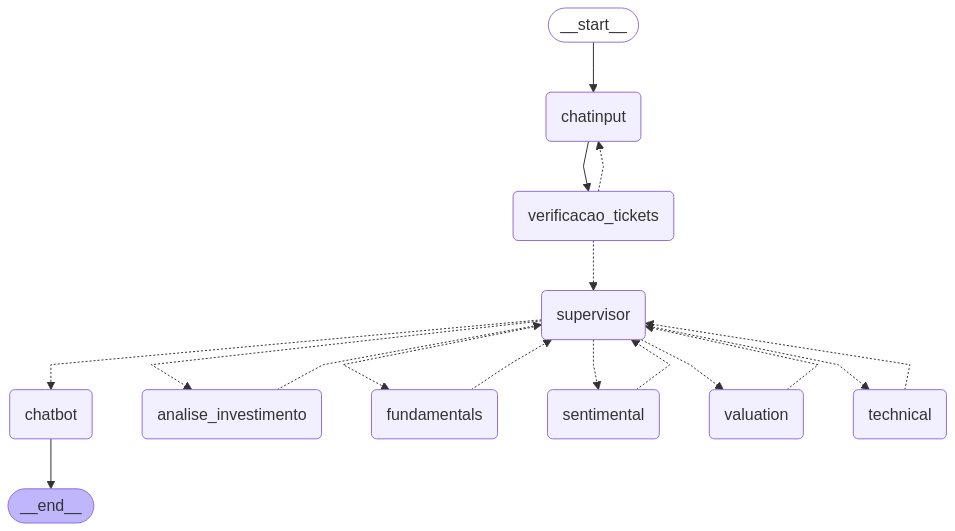

In [14]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [15]:
import time
user_input = [
    # Saudações gerais
    "Bom dia, como está?",
    "Olá, poderia me ajudar?",
    "Boa tarde, gostaria de algumas análises",
    "Oi, preciso de ajuda com investimentos",
    
    # Análises Técnicas
    "Realize uma análise técnica da PETROBRAS",
    "Quero ver a análise técnica da VALE",
    "Me mostre os indicadores técnicos da ITUB4",
    "Poderia fazer uma análise técnica da Banco do BRASIL?",
    "Como está o gráfico técnico da MAGAZ LUIZA?",
    
    # Análises Fundamentalistas
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Preciso dos fundamentos da PETROBRAS",
    "Qual a análise fundamental da VALE?",
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Faça uma análise fundamentalista da ITAU",
    "Como estão os fundamentos da WEG?",
    
    # Análises de Sentimento
    "Qual o sentimento do mercado sobre Unifique?",
    "Análise de sentimento para VALE, por favor",
    "Como está o sentimento para MULTIPLAN?",
    "Faça uma análise de sentimento da OI",
    "Qual a percepção do mercado sobre PETZ?",
    
    # Análises de Valuation
    "Qual o valor justo da AMERICANAS?",
    "Faça uma análise de valuation do Banco do AMAZONIA",
    "Preciso do valuation da BANDO MERCANTIL",
    "Me ajude com o valuation da ECORODOVIAS",
    "Quanto vale realmente a CEMIG?",
    
    # Combinações de Análises
    "Quero análise técnica e fundamental da PETR4",
    "Mostre o sentimento e valuation da VALE3",
    "Preciso de uma análise completa da BBDC3",
    "Como está BRASKEM em termos técnicos e sentimentais?",

    
    # Perguntas Específicas
    
    "Qual o melhor momento para comprar PETR4?",
    "Devo vender minha posição em GERDAU?",
    "É hora de investir em BRAVA?",
    "FLEURY está cara ou barata?",
    "Vale a pena entrar em MAGAZIN LUIZA agora?"
]

    # Configuração do stream
config = {"configurable": {"thread_id": "1"}}

for mess in user_input:
        # Configuração inicial do estado
    print('Pergunta feita:',mess)
    try:
        start = time.time()
        initial_state = {
                "messages": [HumanMessage(content=mess)],
                "ticker": "", 
                "method_analysis": "" ,
                "dados_input" : "",
                "next" : ""
                
            }
    
        events = await graph.ainvoke(
                initial_state,
                config=config,
                stream_mode="values",
            )
        print('Pergunta feita:',mess)
        end = time.time()
        print(f'O tempo de execucao foi de {end - start}')
    except:
        print('Erro na execucao')
        pass
    
    

Pergunta feita: Bom dia, como está?
Entrei na chat imput
Ticker extraído: 
Método de análise: chatbot
Entrei na verificaçao de tickets
Pergunta feita: Bom dia, como está?
O tempo de execucao foi de 1.8641438484191895
Pergunta feita: Olá, poderia me ajudar?
Entrei na chat imput
Ticker extraído: 
Método de análise: chatbot
Entrei na verificaçao de tickets
Pergunta feita: Olá, poderia me ajudar?
O tempo de execucao foi de 1.2371225357055664
Pergunta feita: Boa tarde, gostaria de algumas análises
Entrei na chat imput
Ticker extraído: 
Método de análise: chatbot
Entrei na verificaçao de tickets
Pergunta feita: Boa tarde, gostaria de algumas análises
O tempo de execucao foi de 1.2055859565734863
Pergunta feita: Oi, preciso de ajuda com investimentos
Entrei na chat imput
Ticker extraído: 
Método de análise: chatbot
Entrei na verificaçao de tickets
Pergunta feita: Oi, preciso de ajuda com investimentos
O tempo de execucao foi de 14.297388076782227
Pergunta feita: Realize uma análise técnica da

[*********************100%***********************]  1 of 1 completed


Nao tem returnOnEquity
Diferença entre valuation e cotação: nan%


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Entrei no supervisor
Todos os métodos de análise concluídos
Entrei no chat bot
Pergunta feita: Qual o valor justo da AMERICANAS?
O tempo de execucao foi de 37.8726966381073
Pergunta feita: Faça uma análise de valuation do Banco do AMAZONIA
Entrei na chat imput
Ticker extraído: 
Método de análise: chatbot
Entrei na verificaçao de tickets
Pergunta feita: Faça uma análise de valuation do Banco do AMAZONIA
O tempo de execucao foi de 9.655702114105225
Pergunta feita: Preciso do valuation da BANDO MERCANTIL
Entrei na chat imput
Ticker extraído: 
Método de análise: chatbot
Entrei na verificaçao de tickets
Pergunta feita: Preciso do valuation da BANDO MERCANTIL
O tempo de execucao foi de 42.64811897277832
Pergunta feita: Me ajude com o valuation da ECORODOVIAS
Entrei na chat imput
Ticker extraído: ECOR3
Método de análise: valuation
Entrei na verificaçao de tickets
Entrei no supervisor
Entrei nos valuation


...

Entrei no supervisor
Todos os métodos de análise concluídos
Entrei no chat bot
Pergunta feita: Quanto vale realmente a CEMIG?
O tempo de execucao foi de 56.663116455078125
Pergunta feita: Quero análise técnica e fundamental da PETR4
Entrei na chat imput
Ticker extraído: PETR4
Método de análise: technical,fundamentals
Entrei na verificaçao de tickets
Entrei no supervisor
Pergunta feita: Quero análise técnica e fundamental da PETR4
O tempo de execucao foi de 34.926472663879395
Pergunta feita: Mostre o sentimento e valuation da VALE3
Entrei na chat imput
Ticker extraído: 
Método de análise: chatbot
Entrei na verificaçao de tickets
Pergunta feita: Mostre o sentimento e valuation da VALE3
O tempo de execucao foi de 42.663374185562134
Pergunta feita: Preciso de uma análise completa da BBDC3
Entrei na chat imput
Ticker extraído: BBDC3
Método de análise: Analise_investimento
Entrei na verificaçao de tickets
Entrei no supervisor
Pergunta feita: Preciso de uma análise completa da BBDC3
O tempo d

[*********************100%***********************]  1 of 1 completed


Diferença entre valuation e cotação: -21.74%


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Entrei no supervisor
Todos os métodos de análise concluídos
Entrei no chat bot
Pergunta feita: FLEURY está cara ou barata?
O tempo de execucao foi de 73.97113180160522
Pergunta feita: Vale a pena entrar em MAGAZIN LUIZA agora?
Entrei na chat imput
Ticker extraído: 
Método de análise: chatbot
Entrei na verificaçao de tickets
Pergunta feita: Vale a pena entrar em MAGAZIN LUIZA agora?
O tempo de execucao foi de 21.00901985168457


In [22]:
from langchain_core.prompts import ChatPromptTemplate

state = graph.get_state(config)

ChatPromptTemplate.from_messages(state.values["messages"]).pretty_print()

================================ Human Message =================================

Bom dia, como está?

================================ Human Message =================================

Olá, poderia me ajudar?

================================ Human Message =================================

Boa tarde, gostaria de algumas análises

================================ Human Message =================================

Oi, preciso de ajuda com investimentos

================================ Human Message =================================

Realize uma análise técnica da PETROBRAS

================================== Ai Message ==================================


<think>
Okay, the user is asking for a technical analysis of PETROBRAS. Let me check the data provided. The technical analysis section mentions that the price is above the 20, 100, and 200-day moving averages, indicating a strong uptrend. The RSI is between 52.55 and 87.04, which shows some overbought conditions but also neutral areas. 

In [27]:
events['messages'][-1].content

'Vale a pena entrar em MAGAZIN LUIZA agora?'